# Thai's First Project!:
# Statistical Arbitrage and Mathematical Application to Counter Strike's Skin Market.
* This script is designed to apply mathematical, and statistical concepts into the Counter Stike market, and to provide insights into the market trends, and to help players make informed decisions when buying or selling items. 
* This is strictly for educational use only and should not be applied for real money.
*  I chose this project because I love the game Counter Strike and I have a passion for applying models to these markets! Although it maybe complicated I'll enjoy this project!
## Thesis
* With the upbringing of utilizing mathematical models within prediction market, application of these concepts will provide an edge than buy and hold.

## Hypothesis
* If I apply mathematical and statistical models to Counter-Strike skin markets, then it will outperform buy-and-hold because skin prices exhibit predictable paterns that statistical strategies can systematically cpature before the broad market corrects.

In [5]:
# Import Libraries and Import the basic APIs

# Editor Tip: git pull origin main to commit to the latest version of the code before making changes.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import talib as ta


In [6]:
## User Inputs
name = input("Enter the Dataset Name: ") #ask the user to input the name of the dataset
fast_window = int(input("Enter the Fast Moving Average Window: ")) #ask the user to input the fast moving average window
slow_window = int(input("Enter the Slow Moving Average Window: ")) #ask the user to
initial_equity = float(input("Enter the Initial Equity: ")) #ask the user to input the initial equity


In [7]:

# Load the dataset
df = pd.read_csv('Weapons_Case_Price_Data_CSGO.csv') #load the dataset
day = np.arange(1, len(df) + 1) #add a new column to the dataset with the day number
df['Day'] = day #add the new column to the dataset
df = df[['Date','Day', "Price (USD)", "Volume"]] #Reorder the columns in the dataset
df.loc[0:20] = np.nan #set the broken data for the first 20 rows of the dataset to NaN
df.head() #display the first 5 rows of the dataset


,Date,Day,Price (USD),Volume
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


In [8]:
df.info() #display the information about the dataset 


<class 'pandas.DataFrame'>
RangeIndex: 5059 entries, 0 to 5058
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5038 non-null   str    
 1   Day          5038 non-null   float64
 2   Price (USD)  5038 non-null   float64
 3   Volume       5038 non-null   float64
dtypes: float64(3), str(1)
memory usage: 247.8 KB


## Add and Transform the data
* Lets add a simple linear regression model.
* lets add a simple moving average model.
* lets apply a mean reversion/statistical arbitrage model using oscillators, z scores and standard deviation.
* Correlation Model to speculative markert? (S&P and BTC)?
* Calculate Drawdown and Volatility


In [9]:
## First Get the slope and the regression line of the price over time

slope = (df['Price (USD)'].iloc[-1] - df['Price (USD)'].iloc[0]) / (df['Day'].iloc[-1] - df['Day'].iloc[0]) #calculate the slope
x = df['Day'] #x-axis values
y = df['Price (USD)'] #y-axis values
slope_intercept = df['Price (USD)'].iloc[0] - slope * df['Day'].iloc[0]
regression_line = slope * x + slope_intercept #calculate the regression line
df['Regression Line'] = regression_line #add the regression line to the dataset
df.head()

# Conclusion, This is not a reliable way to predict the price of the item because it underfits the data.
# The price of the item is not increasing at a constant rate, and there are many fluctuations in the price.
# R != > 0.5, which means that the regression line does not fit the data well.

,Date,Day,Price (USD),Volume,Regression Line
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [10]:
## Get Simple Moving Average
df["Fast Moving Average"] = df["Price (USD)"].rolling(window=fast_window).mean()
df["Slow Moving Average"] = df["Price (USD)"].rolling(window=slow_window).mean()

#get crossover signal
df["MA_Signal"] = 0.0
df["MA_Signal"] = np.where(df['Fast Moving Average'] > df['Slow Moving Average'], 1.0, 0.0)
df["Position"] = df["MA_Signal"].diff() #calculate the position of the signal



#Old Pinescript Logic for Equity Calculation, I will convert it to Python using np.where() function

#f df["Signal"] == 1.0:
#    df["Equity"] = initial_equity * (df["Price (USD)"] / df["Price (USD)"].iloc[-1]) 
#elif df["Signal"] == 0.0 and df["Signal"].shift(1) == 1.0:
#    df["Equity"] = initial_equity * (1 - (df["Price (USD)"] / df["Price (USD)"].iloc[-1]))
#else:
#    df["Equity"] = initial_equity

df["Moving_Average_Equity"] = np.where(
    df["MA_Signal"] == 1.0,
    initial_equity * (df["Price (USD)"] / df["Price (USD)"].iloc[-1]),
    np.where(
        (df["MA_Signal"] == 0.0) & (df["MA_Signal"].shift(1) == 1.0),
        initial_equity * (1 - (df["Price (USD)"] / df["Price (USD)"].iloc[-1])),
        initial_equity
    )
)
df.head()



,Date,Day,Price (USD),Volume,Regression Line,Fast Moving Average,Slow Moving Average,MA_Signal,Position,Moving_Average_Equity
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,10.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,10.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,10.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,10.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,10.0


In [12]:
# Calculate Some Oscillators to get a better understanding of the price action
#Stochastic Oscillator
k_window = int(input("Enter K Window for Stochastic Oscillator: ")) #ask the user to input the K window for the stochastic oscillator
def stochastic_oscillator(df, k_window=14, d_window=3):
    Lowest_Low= df["Price (USD)"].rolling(window=k_window).min()
    Highest_High= df["Price (USD)"].rolling(window=k_window).max()
    Stochastic_K = 100 * (df["Price (USD)"]- Lowest_Low) / (Highest_High - Lowest_Low)
    return Stochastic_K

df["Stochastic K%"] = stochastic_oscillator(df, k_window=k_window)


linear_regression_window = int(input("Enter the Linear Regression Window: ")) #ask the user to input the linear regression window
#Get a Regular Polynomial Regression Line for the price action
# Formula = y = mx + b, where m is the slope and b is the intercept
df["Linear Regression"] = ta.LINEARREG(df["Price (USD)"], timeperiod=linear_regression_window) #calculate the linear regression line using the pandas-ta library

lsma_length        = int(input("Enter the LSMA Length: "))
a          = int(input("Enter the starting value for the For Loop: "))
b          = int(input("Enter the ending value for the For Loop: "))


def lsmaforloop(df= df["Price (USD)"], window=2, a=10,b=60):
    subject = ta.LINEARREG(df["Price (USD)"], timeperiod=window)
    total = 0.0
    for i in range(a, b + 1):
        total += np.where(subject > subject.shift(i), 1, -1)
    return total

df["LSMA For Loop"] = lsmaforloop(df, lsma_length, a, b)



In [ ]:
## Calculate Returns

# Buy and Hold Returns
df["Buy and Hold Returns"] = initial_equity * (df["Price (USD)"] / df["Price (USD)"].iloc[-1])

## Plot the Data and Analyze

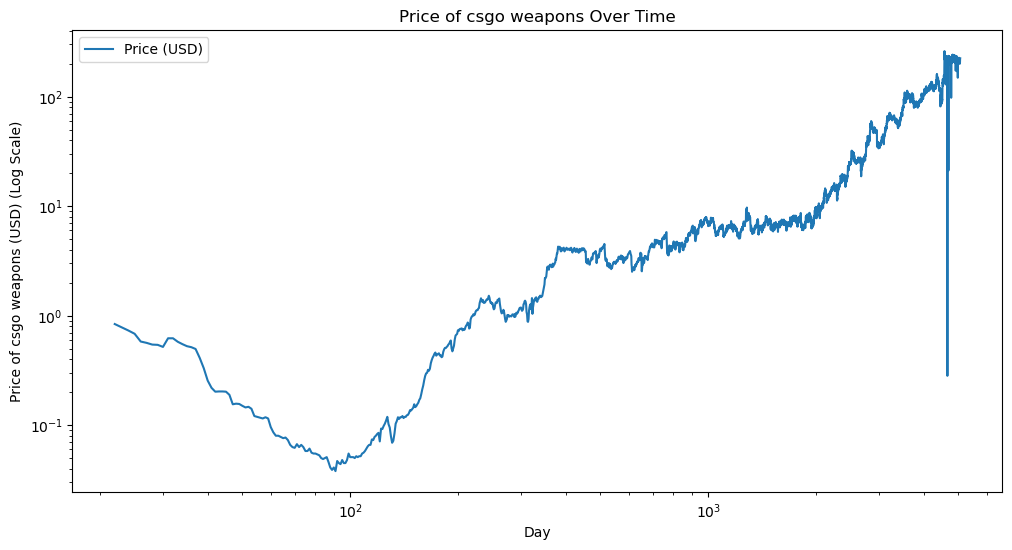

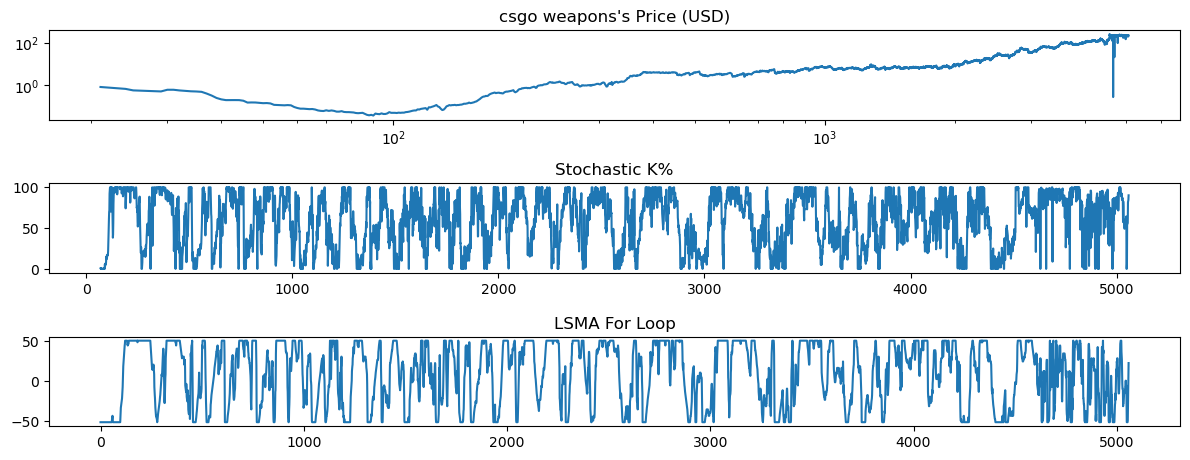

In [ ]:


plt.figure(figsize=(12,6))
plt.loglog(df["Day"], df["Price (USD)"], label="Price (USD)")
plt.xlabel("Day")
plt.ylabel(f"Price of {name} (USD) (Log Scale)")
plt.title(f"Price of {name} Over Time")
plt.legend()
plt.show()

# Subplots Indicators and Mathematical Analysis
plt.figure(figsize=(12,6))

plt.subplot(4,1,1)
plt.loglog(df["Price (USD)"])
plt.title(f"{name}'s Price (USD)")

plt.subplot(4,1,2)
plt.plot(df["Stochastic K%"])
plt.title("Stochastic K%")

plt.subplot(4,1,3)
plt.plot(df["LSMA For Loop"])
plt.title("LSMA For Loop")


plt.tight_layout()
plt.show()




## Final Conclusion